In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from typing import List
import os

In [112]:
AvaBuildLand = pd.read_csv("Ava_Streets_Table.csv")
AvaBuildLand.head()

,Unnamed: 0,A_Properties,A_Current_Owner,A_Account_Num,A_SQFT
0,1,3000 S 28TH ST,\r\r\n\t\t\t\t\t\tCITY OF ALEXANDRIA\t\t,50299410,1
1,2,3102 S 28TH ST,\r\r\n\t\t\t\t\t\tALEXANDRIA REDEVELOPMENTHOUS...,50299400,1
2,3,"3200 S 28TH ST, UNIT 101",\r\r\n\t\t\t\t\t\tBEGUM SAIRAKHALEK MOHAMMAD A...,50466800,1090
3,4,"3200 S 28TH ST, UNIT 102",\r\r\n\t\t\t\t\t\tCHESLEY JOHN W III AND JUDIT...,50466810,1280
4,5,"3200 S 28TH ST, UNIT 201",\r\r\n\t\t\t\t\t\tSILVA HUGO TRNEGRONI ANDREA ...,50466820,700


In [113]:
AvaBuildingLand = pd.read_csv("ABuildingLand.csv")
AvaBuildingLand

,Unnamed: 0,Num,A_Levy_Year,A_Land_Value,A_Building_Value,A_Total_Value,A_Zip_Code
0,1,50299410,01/2025,"$1,375,389",$0,"$1,375,389",22313
1,2,50299410,01/2024,"$1,375,389",$0,"$1,375,389",22313
2,3,50299410,01/2023,"$1,375,389",$0,"$1,375,389",22313
3,4,50299410,01/2022,"$1,375,389",$0,"$1,375,389",22313
4,5,50299410,01/2021,"$1,375,389",$0,"$1,375,389",22313
...,...,...,...,...,...,...,...
981399,981400,26312030,01/2004,"$373,800","$410,000","$783,800",22304
981400,981401,26312030,01/2003,"$287,500","$416,400","$703,900",22304
981401,981402,26312030,01/2002,"$230,000","$422,800","$652,800",22304
981402,981403,26312030,01/2001,"$200,000","$363,800","$563,800",22304


In [114]:
AvaBuildingLand.columns

Index(['Unnamed: 0', 'Num', 'A_Levy_Year', 'A_Land_Value', 'A_Building_Value',
       'A_Total_Value', 'A_Zip_Code'],
      dtype='object')

In [115]:
ABLCopy = AvaBuildingLand.copy()
ABLCopy = ABLCopy.rename(columns = {"Unnamed: 0": "Property Record", "Num": "Account Number", "A_Levy_Year": "Levy Year",
                      "A_Land_Value": "Land Value", "A_Building_Value": "Building Value", "A_Total_Value": "Total Value", "A_Zip_Code": "Zip Code"}
          )
ABLCopy.head()

,Property Record,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
0,1,50299410,01/2025,"$1,375,389",$0,"$1,375,389",22313
1,2,50299410,01/2024,"$1,375,389",$0,"$1,375,389",22313
2,3,50299410,01/2023,"$1,375,389",$0,"$1,375,389",22313
3,4,50299410,01/2022,"$1,375,389",$0,"$1,375,389",22313
4,5,50299410,01/2021,"$1,375,389",$0,"$1,375,389",22313


In [116]:
ABLCopy = ABLCopy.set_index("Property Record")
ABLCopy.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
Property Record,,,,,,
1,50299410,01/2025,"$1,375,389",$0,"$1,375,389",22313
2,50299410,01/2024,"$1,375,389",$0,"$1,375,389",22313
3,50299410,01/2023,"$1,375,389",$0,"$1,375,389",22313
4,50299410,01/2022,"$1,375,389",$0,"$1,375,389",22313
5,50299410,01/2021,"$1,375,389",$0,"$1,375,389",22313


In [117]:
ABLCopy.dtypes

Account Number     int64
Levy Year         object
Land Value        object
Building Value    object
Total Value       object
Zip Code           int64
dtype: object

In [118]:
def extract_value(df, columns: List[str]):
    for column in columns:
        df[column] = df[column].str.extract("(\d{1,3}(?:,\d{3})*|\d+)")
        df[column] = df[column].str.replace(",", "")
        df[column] = df[column].astype(float)
        df[column] = df[column].astype(int)

    return df

In [119]:
value_columns = ["Land Value", "Building Value", "Total Value"]
ABLCopy = extract_value(ABLCopy, value_columns)

In [120]:
ABLCopy.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
Property Record,,,,,,
1,50299410,01/2025,1375389,0,1375389,22313
2,50299410,01/2024,1375389,0,1375389,22313
3,50299410,01/2023,1375389,0,1375389,22313
4,50299410,01/2022,1375389,0,1375389,22313
5,50299410,01/2021,1375389,0,1375389,22313


In [121]:
ABLCopy[ABLCopy['Account Number'] == 50467490].head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
Property Record,,,,,,
1847,50467490,01/2025,86036,160214,246250,6410
1848,50467490,01/2024,86036,149783,235819,6410
1849,50467490,01/2023,80323,139837,220160,6410
1850,50467490,01/2022,76498,133178,209676,6410
1851,50467490,01/2021,76498,133178,209676,6410


Write a function that will essentailly replace the invalid zip code, with the correct one, only if the first column above and below match are are also valid zip codes!!!

In [123]:
ABLCopy['Levy Year'] = ABLCopy['Levy Year'].astype(str)
ABLCopy['Levy Year'] = ABLCopy['Levy Year'].str.replace("01/", "")
ABLCopy['Levy Year'] = ABLCopy['Levy Year'].str.extract(r'(\d{4})')
ABLCopy['Levy Year'] = ABLCopy['Levy Year'].astype(float)
ABLCopy['Levy Year'] = ABLCopy['Levy Year'].astype(int)
ABLCopy.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
Property Record,,,,,,
1,50299410,2025,1375389,0,1375389,22313
2,50299410,2024,1375389,0,1375389,22313
3,50299410,2023,1375389,0,1375389,22313
4,50299410,2022,1375389,0,1375389,22313
5,50299410,2021,1375389,0,1375389,22313


In [124]:
ABLCopy.dtypes

Account Number    int64
Levy Year         int32
Land Value        int32
Building Value    int32
Total Value       int32
Zip Code          int64
dtype: object

In [138]:
valid_zip_codes = [22312, 22311, 22302, 22206, 22304, 22305, 22301, 22314]

ValidZipABL = ABLCopy[ABLCopy['Zip Code'].isin(valid_zip_codes)]
ValidZipABL.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
Property Record,,,,,,
27,50299400,2025,3031482,1364125,4395607,22314
28,50299400,2024,3031482,1364125,4395607,22314
29,50299400,2023,3031482,1364125,4395607,22314
30,50299400,2022,3031482,1364125,4395607,22314
31,50299400,2021,3031482,1364125,4395607,22314


In [140]:
ValidZipABL.to_csv("ValidZipCodeData.csv", index = False)

In [142]:
folder_name = "Alexandria Personal Project"
os.makedirs(folder_name, exist_ok=True)
file_path = os.path.join(folder_name, "ValidZipCodeData.csv")
ValidZipABL.to_csv(file_path, index=False)
print(f"CSV saved to :{file_path}")

CSV saved to :Alexandria Personal Project\ValidZipCodeData.csv


In [144]:
len(ValidZipABL)

812332

In [146]:
NonValidZipABL = ABLCopy[~ABLCopy['Zip Code'].isin(valid_zip_codes)]
NonValidZipABL.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
Property Record,,,,,,
1,50299410,2025,1375389,0,1375389,22313
2,50299410,2024,1375389,0,1375389,22313
3,50299410,2023,1375389,0,1375389,22313
4,50299410,2022,1375389,0,1375389,22313
5,50299410,2021,1375389,0,1375389,22313


In [48]:
len(ValidZipABL)

823226

In [603]:
ABLCopy_ZipGroup = ABLCopy.groupby(["Zip Code"]).agg({"Levy Year": list, "Land Value": list, "Building Value": list, "Total Value": list, "Account Number": list})
ABLCopy_ZipGroup.head()

,Levy Year,Land Value,Building Value,Total Value,Account Number
Zip Code,,,,,
694,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...","[85947, 83850, 83850, 82206, 79045, 71859, 677...","[170639, 151000, 140478, 137723, 132426, 12038...","[256586, 234850, 224328, 219929, 211471, 19224...","[50229230, 50229230, 50229230, 50229230, 50229..."
908,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...","[1970709, 1876865, 1770628, 1735910, 1685349, ...","[1866524, 1771642, 1646352, 1615800, 1571307, ...","[3837233, 3648507, 3416980, 3351710, 3256656, ...","[60029360, 60029360, 60029360, 60029360, 60029..."
918,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...","[112878, 111484, 111484, 109298, 121442, 10747...","[222832, 199620, 195706, 191869, 213187, 18866...","[335710, 311104, 307190, 301167, 334629, 29613...","[50225280, 50225280, 50225280, 50225280, 50225..."
927,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...","[102606, 96716, 95286, 90749, 87259, 84717, 79...","[231170, 213730, 203552, 193859, 186403, 18097...","[333776, 310446, 298838, 284608, 273662, 26569...","[50560100, 50560100, 50560100, 50560100, 50560..."
936,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...","[195534, 181050, 177500, 177500, 177500, 17750...","[618491, 618491, 606870, 606870, 606870, 56885...","[814025, 799541, 784370, 784370, 784370, 74635...","[50666060, 50666060, 50666060, 50666060, 50666..."


In [604]:
ValidZipABL_ZipGroup = ValidZipABL.groupby(["Zip Code", "Levy Year"]).agg({"Land Value": list, "Building Value": list, "Total Value": list, "Account Number": list})
ValidZipABL_ZipGroup.head()

Land Value  \
Zip Code Levy Year                                                      
22206    2000       [30000, 0, 29500, 29500, 29500, 30000, 27200, ...   
         2001       [30000, 0, 29500, 29500, 29500, 30000, 27200, ...   
         2002       [31500, 0, 31000, 31000, 31000, 31500, 28600, ...   
         2003       [52100, 0, 51200, 51200, 51200, 52100, 47300, ...   
         2004       [67700, 0, 66600, 66600, 66600, 67700, 61500, ...   

                                                       Building Value  \
Zip Code Levy Year                                                      
22206    2000       [110100, 0, 108800, 108800, 108800, 110100, 10...   
         2001       [124200, 0, 122700, 122700, 122700, 124200, 11...   
         2002       [157000, 0, 155100, 155100, 155100, 157000, 14...   
         2003       [200100, 0, 197700, 197700, 197700, 200100, 18...   
         2004       [222300, 0, 219600, 219600, 219600, 222300, 20...   

                                                          Total Value  \
Zip Code Levy Year                                                      
22206    2000       [140100, 0, 138300, 138300, 138300, 140100, 12...   
         2001       [154200, 0, 152200, 152200, 152200, 154200, 14...   
         2002       [188500, 0, 186100, 186100, 186100, 188500, 17...   
         2003       [252200, 0, 248900, 248900, 248900, 252200, 22...   
         2004       [290000, 0, 286200, 286200, 286200, 290000, 26...   

                                                       Account Number  
Zip Code Levy Year                                                     
22206    2000       [50227240, 50213000, 50227260, 50227270, 50227...  
         2001       [50227240, 50213000, 50227260, 50227270, 50227...  
         2002       [50227240, 50213000, 50227260, 50227270, 50227...  
         2003       [50227240, 50213000, 50227260, 50227270, 50227...  
         2004       [50227240, 50213000, 50227260, 50227270, 50227...

In [605]:
ZipCode_22206 = ValidZipABL_ZipGroup.loc[22206]
ZipCode_22206.head()

,Land Value,Building Value,Total Value,Account Number
Levy Year,,,,
2000,"[30000, 0, 29500, 29500, 29500, 30000, 27200, ...","[110100, 0, 108800, 108800, 108800, 110100, 10...","[140100, 0, 138300, 138300, 138300, 140100, 12...","[50227240, 50213000, 50227260, 50227270, 50227..."
2001,"[30000, 0, 29500, 29500, 29500, 30000, 27200, ...","[124200, 0, 122700, 122700, 122700, 124200, 11...","[154200, 0, 152200, 152200, 152200, 154200, 14...","[50227240, 50213000, 50227260, 50227270, 50227..."
2002,"[31500, 0, 31000, 31000, 31000, 31500, 28600, ...","[157000, 0, 155100, 155100, 155100, 157000, 14...","[188500, 0, 186100, 186100, 186100, 188500, 17...","[50227240, 50213000, 50227260, 50227270, 50227..."
2003,"[52100, 0, 51200, 51200, 51200, 52100, 47300, ...","[200100, 0, 197700, 197700, 197700, 200100, 18...","[252200, 0, 248900, 248900, 248900, 252200, 22...","[50227240, 50213000, 50227260, 50227270, 50227..."
2004,"[67700, 0, 66600, 66600, 66600, 67700, 61500, ...","[222300, 0, 219600, 219600, 219600, 222300, 20...","[290000, 0, 286200, 286200, 286200, 290000, 26...","[50227240, 50213000, 50227260, 50227270, 50227..."


In [606]:
ZipCode_22206 = ZipCode_22206.reset_index()
ZipCode_22206.head()

,Levy Year,Land Value,Building Value,Total Value,Account Number
0,2000,"[30000, 0, 29500, 29500, 29500, 30000, 27200, ...","[110100, 0, 108800, 108800, 108800, 110100, 10...","[140100, 0, 138300, 138300, 138300, 140100, 12...","[50227240, 50213000, 50227260, 50227270, 50227..."
1,2001,"[30000, 0, 29500, 29500, 29500, 30000, 27200, ...","[124200, 0, 122700, 122700, 122700, 124200, 11...","[154200, 0, 152200, 152200, 152200, 154200, 14...","[50227240, 50213000, 50227260, 50227270, 50227..."
2,2002,"[31500, 0, 31000, 31000, 31000, 31500, 28600, ...","[157000, 0, 155100, 155100, 155100, 157000, 14...","[188500, 0, 186100, 186100, 186100, 188500, 17...","[50227240, 50213000, 50227260, 50227270, 50227..."
3,2003,"[52100, 0, 51200, 51200, 51200, 52100, 47300, ...","[200100, 0, 197700, 197700, 197700, 200100, 18...","[252200, 0, 248900, 248900, 248900, 252200, 22...","[50227240, 50213000, 50227260, 50227270, 50227..."
4,2004,"[67700, 0, 66600, 66600, 66600, 67700, 61500, ...","[222300, 0, 219600, 219600, 219600, 222300, 20...","[290000, 0, 286200, 286200, 286200, 290000, 26...","[50227240, 50213000, 50227260, 50227270, 50227..."


In [608]:
ZipCode_22206['Total Value Sum'] = ZipCode_22206['Total Value'].apply(lambda x: sum(x))
ZipCode_22206['Average Total Value'] = ZipCode_22206['Total Value'].apply(lambda x: np.mean(x))
ZipCode_22206.head()

,Levy Year,Land Value,Building Value,Total Value,Account Number,Total Value Sum,Average Total Value
0,2000,"[30000, 0, 29500, 29500, 29500, 30000, 27200, ...","[110100, 0, 108800, 108800, 108800, 110100, 10...","[140100, 0, 138300, 138300, 138300, 140100, 12...","[50227240, 50213000, 50227260, 50227270, 50227...",27262500,116506.410256
1,2001,"[30000, 0, 29500, 29500, 29500, 30000, 27200, ...","[124200, 0, 122700, 122700, 122700, 124200, 11...","[154200, 0, 152200, 152200, 152200, 154200, 14...","[50227240, 50213000, 50227260, 50227270, 50227...",29865000,127628.205128
2,2002,"[31500, 0, 31000, 31000, 31000, 31500, 28600, ...","[157000, 0, 155100, 155100, 155100, 157000, 14...","[188500, 0, 186100, 186100, 186100, 188500, 17...","[50227240, 50213000, 50227260, 50227270, 50227...",35908300,153454.273504
3,2003,"[52100, 0, 51200, 51200, 51200, 52100, 47300, ...","[200100, 0, 197700, 197700, 197700, 200100, 18...","[252200, 0, 248900, 248900, 248900, 252200, 22...","[50227240, 50213000, 50227260, 50227270, 50227...",47537600,203152.136752
4,2004,"[67700, 0, 66600, 66600, 66600, 67700, 61500, ...","[222300, 0, 219600, 219600, 219600, 222300, 20...","[290000, 0, 286200, 286200, 286200, 290000, 26...","[50227240, 50213000, 50227260, 50227270, 50227...",56156800,239986.324786


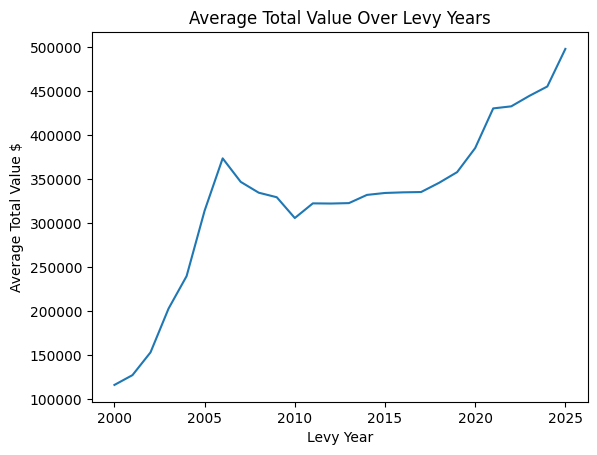

In [609]:
plt.plot(ZipCode_22206['Levy Year'], ZipCode_22206['Average Total Value'])
plt.xlabel('Levy Year')
plt.ylabel('Average Total Value $')
plt.title('Average Total Value Over Levy Years')
plt.show()

In [611]:
unique_zip_codes = ValidZipABL_ZipGroup.index.get_level_values('Zip Code').unique()

total_value_sum_list = []
average_total_value_list = []

for zipcode in unique_zip_codes:
    CurrZipCode = ValidZipABL_ZipGroup.loc[zipcode]
    
    CurrZipCode = CurrZipCode.reset_index()
    
    total_value_sum = CurrZipCode['Total Value'].apply(lambda x: sum(x))
    average_total_value = CurrZipCode['Total Value'].apply(lambda x: np.mean(x))
    
    total_value_sum_list.extend(total_value_sum)
    average_total_value_list.extend(average_total_value)

ValidZipABL_ZipGroup = ValidZipABL_ZipGroup.reset_index()
ValidZipABL_ZipGroup['Total Value Sum'] = total_value_sum_list
ValidZipABL_ZipGroup['Average Total Value'] = average_total_value_list 
ValidZipABL_ZipGroup.head()

,Zip Code,Levy Year,Land Value,Building Value,Total Value,Account Number,Total Value Sum,Average Total Value
0,22206,2000,"[30000, 0, 29500, 29500, 29500, 30000, 27200, ...","[110100, 0, 108800, 108800, 108800, 110100, 10...","[140100, 0, 138300, 138300, 138300, 140100, 12...","[50227240, 50213000, 50227260, 50227270, 50227...",27262500,116506.410256
1,22206,2001,"[30000, 0, 29500, 29500, 29500, 30000, 27200, ...","[124200, 0, 122700, 122700, 122700, 124200, 11...","[154200, 0, 152200, 152200, 152200, 154200, 14...","[50227240, 50213000, 50227260, 50227270, 50227...",29865000,127628.205128
2,22206,2002,"[31500, 0, 31000, 31000, 31000, 31500, 28600, ...","[157000, 0, 155100, 155100, 155100, 157000, 14...","[188500, 0, 186100, 186100, 186100, 188500, 17...","[50227240, 50213000, 50227260, 50227270, 50227...",35908300,153454.273504
3,22206,2003,"[52100, 0, 51200, 51200, 51200, 52100, 47300, ...","[200100, 0, 197700, 197700, 197700, 200100, 18...","[252200, 0, 248900, 248900, 248900, 252200, 22...","[50227240, 50213000, 50227260, 50227270, 50227...",47537600,203152.136752
4,22206,2004,"[67700, 0, 66600, 66600, 66600, 67700, 61500, ...","[222300, 0, 219600, 219600, 219600, 222300, 20...","[290000, 0, 286200, 286200, 286200, 290000, 26...","[50227240, 50213000, 50227260, 50227270, 50227...",56156800,239986.324786


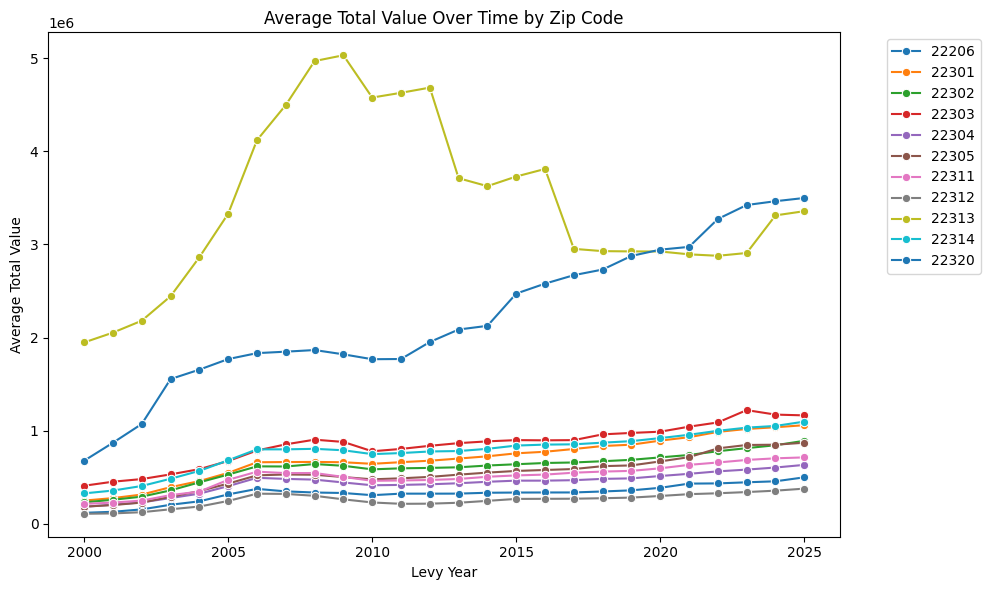

In [627]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=ValidZipABL_ZipGroup, 
    x='Levy Year', 
    y='Average Total Value', 
    hue='Zip Code', 
    marker='o', 
    palette='tab10'
)

plt.xlabel('Levy Year')
plt.ylabel('Average Total Value')
plt.title('Average Total Value Over Time by Zip Code')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()